
# 🏷️ Logistic Regression - Multivariable

---

## 🎯 Objectius
- Mostrar un exemple d'us del model de classificació **Logistic Regression**. Multivariable


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Exemple: Social network advertising
https://www.kaggle.com/datasets/akram24/social-network-ads

La publicitat en xarxes socials, també anomenada segmentació a les xarxes socials, fa referència al desenvolupament d’estratègies de publicitat en línia dins dels serveis de xarxes socials. L’objectiu és aprofitar la informació demogràfica dels usuaris (edat, salari, etc.) disponible a través de la mateixa plataforma i dirigir els anuncis adequadament per arribar als usuaris potencialment més interessats en els productes.

L’objectiu d’aquest conjunt de dades és avaluar el resultat d’una estratègia de publicitat en línia dissenyada específicament per segmentar usuaris més grans i/o amb més recursos

In [10]:
path = "/content/drive/MyDrive/Colab Notebooks/M0572-SistemesAprenentatgeAutomatic/02_models_supervisats/dataset/Social_Network_Ads.csv"
df = pd.read_csv(path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


* L'objectiu és una variable binària que indica si l'usuari acaba fent clic a l'anunci

In [11]:
df.Purchased.value_counts()

,count
Purchased,
0,257
1,143


* Informació repsecte dades numèriques

In [12]:
df[['Age', 'EstimatedSalary']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,400.0,37.655,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,69742.500,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0


In [13]:
# Afegir una variable dummy no factoritzar
# to include 'gender' in our regression model we need to transform it into a numerical binary variable
df['Gender'] = df.Gender.factorize()[0]
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19.0,19000.0,0
1,15810944,0,35.0,20000.0,0
2,15668575,1,26.0,43000.0,0
3,15603246,1,27.0,57000.0,0
4,15804002,0,19.0,76000.0,0


## Construim el model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test = train_test_split(df, test_size = 0.20, random_state = 14782)
X_train.shape, X_test.shape

((320, 5), (80, 5))

In [15]:
predictors = df.columns[[1, 2, 3]]
predictors

Index(['Gender', 'Age', 'EstimatedSalary'], dtype='object')

In [16]:
to_predict = df.columns[[4]]
to_predict

Index(['Purchased'], dtype='object')

In [17]:
#hem de fer un ravel per obtenir un columvector perquè to_predict és un dataset.
model = LogisticRegression().fit(X_train[predictors], X_train[to_predict].to_numpy().ravel())

In [18]:
X_test['predict'] = model.predict(X_test[predictors])

In [19]:
# Coeficients
print(f'\u03B21: {0}, \u03B22: {1}, ',model.coef_.item(0),model.coef_.item(1))
# Intercept (x = 0)
print('\u03B20: %.5f' % model.intercept_.item())
# error
print('R^2:', model.score(X_test[predictors], X_test[to_predict]))

β1: 0, β2: 1,  -0.352467423211764 0.23302723343673984
β0: -12.56103
R^2: 0.8125


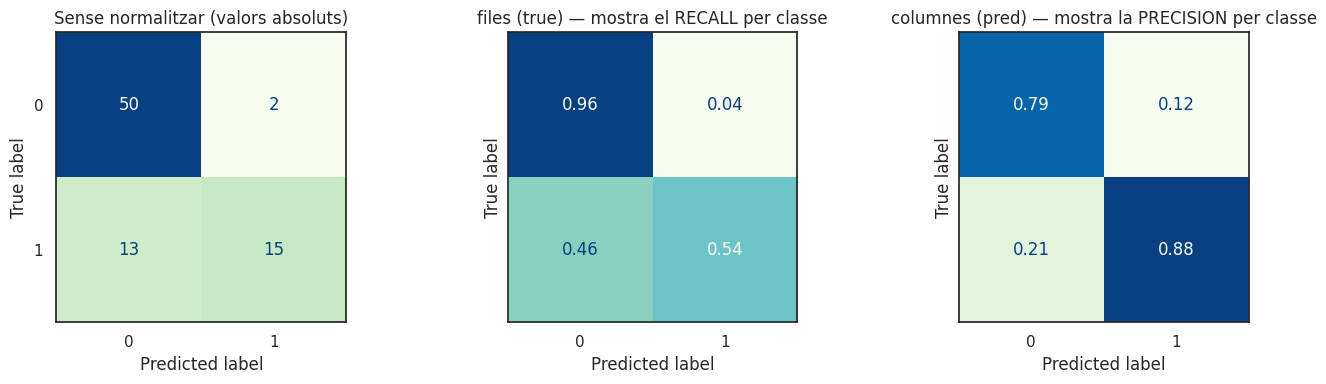

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
sns.set_theme(context = 'notebook', style = "white", font_scale = 1.0)
_, axs = plt.subplots(1, 3, figsize = (14, 4), sharey = True)
titles = [
    "Sense normalitzar (valors absoluts)",
    "files (true) — mostra el RECALL per classe",
    "columnes (pred) — mostra la PRECISION per classe"
]
normalizations = [None, 'true', 'pred']
#for i, norm in enumerate([None, 'true', 'pred']):
for ax, norm, title in zip(axs.flatten(), normalizations, titles):
    ConfusionMatrixDisplay.from_predictions(
        X_test.Purchased,
        X_test.predict,
        normalize = norm,
        values_format = '.2f' if norm is not None else '.0f',
        ax = ax,
        colorbar = False,
        cmap = 'GnBu'
    )
    ax.set_title(title)
plt.tight_layout();

In [21]:
X_test.predict.value_counts()

,count
predict,
0,63
1,17


### Scaling the predictors

* Observem que el rang del salari és molt més gran que el rang de l'edat. Per tant, una opció seria realitzar un escalat de les dades per estandaritzar.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df[predictors]), columns = predictors)
df_scaled[to_predict] = df[to_predict]

df_scaled.describe()


,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,4.000000e+02,4.000000e+02,400.000000
mean,-8.881784e-18,-7.105427e-17,-1.776357e-17,0.357500
std,1.001252e+00,1.001252e+00,1.001252e+00,0.479864
min,-1.020204e+00,-1.877311e+00,-1.607506e+00,0.000000
25%,-1.020204e+00,-7.550313e-01,-7.852897e-01,0.000000
50%,9.801961e-01,-6.256110e-02,7.561451e-03,0.000000
75%,9.801961e-01,7.970571e-01,5.361289e-01,1.000000
max,9.801961e-01,2.134241e+00,2.356750e+00,1.000000


In [26]:
Z_train, Z_test = train_test_split(df_scaled, test_size = 0.2, random_state = 1234)
model_scaled = LogisticRegression().fit(Z_train[predictors], Z_train[to_predict].to_numpy().ravel())

In [29]:
Z_test['predict'] = model_scaled.predict(Z_test[predictors])

In [27]:
# Coeficients
print(f'\u03B21: {0}, \u03B22: {1}, ',model_scaled.coef_.item(0),model_scaled.coef_.item(1))
# Intercept (x = 0)
print('\u03B20: %.5f' % model_scaled.intercept_.item())
# error
print('R^2:', model_scaled.score(Z_test[predictors], Z_test[to_predict]))

β1: 0, β2: 1,  -0.15147415918354096 2.479930088645945
β0: -1.11951
R^2: 0.8375


In [30]:
Z_test.predict.value_counts()

,count
predict,
0,54
1,26


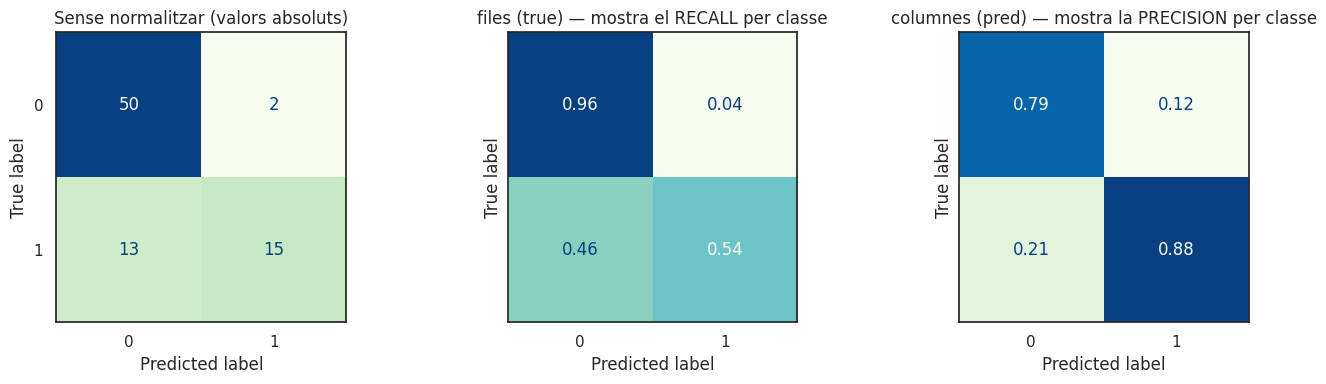

In [31]:
_, axs = plt.subplots(1, 3, figsize = (14, 4), sharey = True)
titles = [
    "Sense normalitzar (valors absoluts)",
    "files (true) — mostra el RECALL per classe",
    "columnes (pred) — mostra la PRECISION per classe"
]
normalizations = [None, 'true', 'pred']
#for i, norm in enumerate([None, 'true', 'pred']):
for ax, norm, title in zip(axs.flatten(), normalizations, titles):
    ConfusionMatrixDisplay.from_predictions(
        X_test.Purchased,
        X_test.predict,
        normalize = norm,
        values_format = '.2f' if norm is not None else '.0f',
        ax = ax,
        colorbar = False,
        cmap = 'GnBu'
    )
    ax.set_title(title)
plt.tight_layout();